### 📘 FD003 – Phase 3: Classification and Evaluation Summary

This phase focuses on building a robust multi-class classification model to predict the **degradation stage (0 to 4)** of engines in the FD003 dataset. The approach follows an industrial and scientific methodology, emphasizing both model accuracy and generalization, with proper validation.

---

#### **1. Objective**
To classify each engine cycle in FD003 into one of five degradation stages using sensor data, supporting proactive maintenance planning and remaining useful life estimation.

---

#### **2. Methodology Overview**

1. **Feature Selection:**
   - Selected top 5 high-variance sensors: `sensor_11`, `sensor_12`, `sensor_7`, `sensor_17`, `sensor_4`.

2. **Train-Test Split:**
   - Stratified split (80:20) preserving class balance:
     - Train samples: 19,776
     - Test samples: 4,944

3. **Model Candidates:**
   - Random Forest (Tuned via Grid Search)
   - XGBoost
   - Support Vector Machine (SVM)
   - Logistic Regression

4. **Random Forest Tuning:**
   - GridSearchCV over 24 parameter combinations
   - 5-fold Stratified Cross-Validation
   - Best parameters:
     - `n_estimators = 200`
     - `max_depth = 10`
     - `min_samples_split = 2`
     - `min_samples_leaf = 1`

5. **Model Training:**
   - All models trained on the same dataset and feature set for fair comparison.
   - Classification reports, confusion matrices (raw and normalized), and F1 macro scores computed.

6. **Sanity Checks (Performed for RF):**
   - **Sanity A:** CV with shuffled labels → Low mean F1 (~0.18) confirmed no data leakage.
   - **Sanity B:** Correlation of sensor features with stage labels.
   - **Sanity C:** Depth-2 tree diagnostic test to verify non-linearity handling.

---

#### **3. Evaluation Metrics**

| Metric            | RF (Tuned) | SVM     | Logistic Reg. | XGBoost |
|-------------------|-----------:|--------:|--------------:|--------:|
| **Train Accuracy**|   0.9493   | 0.9314  | 0.9302        | 0.9549  |
| **Test Accuracy** |   0.9177   | 0.9286  | 0.9290        | 0.9335  |
| **CV F1 (Mean)**  |   0.9222   | 0.9283  | 0.9280        | 0.9282  |

- **XGBoost** showed the highest test accuracy (0.9335), slightly outperforming others.
- **Random Forest (Tuned)** had strong generalization and interpretability, confirmed by feature importance analysis.
- All models performed closely on macro-averaged F1, validating the robustness of the feature set and preprocessing.

---

#### **4. Visualizations Generated**

- Train and Test **Confusion Matrices** (raw and normalized)
- Final **Bar Plot** comparing model-wise Test Accuracy
- **Feature Importance Plot** for Random Forest

All figures are saved under:
```
../../figures/phase3/
```

Classification reports and comparison tables are saved under:
```
../../report/
```

---

#### **5. Outcome**
The FD003 classifier is now production-ready, capable of classifying degradation stages with high precision and recall. The pipeline is validated across multiple models, with clear interpretability and scientific rigor.


# Step 0: Setup Environment — Hybrid Predictive Maintenance (FD003)

In [1]:
# Step 0: Setup Environment — Hybrid Predictive Maintenance (FD003)

# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 2. Plot Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 3. Create Required Directories
required_dirs = [
    os.path.join('..', '..', 'figures', 'phase3'),
    os.path.join('..', '..', 'models'),
    os.path.join('..', '..', 'report')
]

for path in required_dirs:
    os.makedirs(path, exist_ok=True)
    print(f" Directory ensured: {path}")

# 4. Set Random Seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("\n✅ Step 0 Complete — FD003 environment setup is ready.\n")


 Directory ensured: ..\..\figures\phase3
 Directory ensured: ..\..\models
 Directory ensured: ..\..\report

✅ Step 0 Complete — FD003 environment setup is ready.



# Step 1: Load Corrected Dataset (FD003)

In [2]:
# Step 1: Load Corrected Dataset (FD003)

import pandas as pd
import os

# Define the file path (two levels up)
data_path_fd003 = os.path.join('..', '..', 'data', 'corrected_clustered_train_FD003.csv')

# Load dataset
df_fd003 = pd.read_csv(data_path_fd003)
print(f"Dataset loaded: {data_path_fd003}")

# Preview first few rows
print("\nPreview of first 5 rows:")
display(df_fd003.head())

# Dataset info
print("\nDataset Info:")
print(df_fd003.info())

# Column names
print("\nAvailable Columns:")
print(df_fd003.columns.tolist())

# Target class distribution
print("\nClass Distribution (kmeans_stage):")
print(df_fd003['kmeans_stage'].value_counts().sort_index())


Dataset loaded: ..\..\data\corrected_clustered_train_FD003.csv

Preview of first 5 rows:


,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,...,sensor_20,sensor_21,kmeans_cluster,agglo_cluster,kmeans_stage,agglo_stage,pca_1,pca_2,tsne_1,tsne_2
0,1,1,-0.0005,0.0004,100.0,0.355972,0.370523,0.308580,0.0,1.0,...,0.559524,0.446331,4,2,Stage 4,Stage 2,-0.188882,-0.102427,-33.062656,-7.281364
1,1,2,0.0008,-0.0003,100.0,0.388759,0.399100,0.309360,0.0,1.0,...,0.488095,0.534836,4,2,Stage 4,Stage 2,-0.143457,-0.066518,-8.688438,-1.960224
2,1,3,-0.0014,-0.0002,100.0,0.313817,0.353298,0.445398,0.0,1.0,...,0.404762,0.458577,4,2,Stage 4,Stage 2,-0.173302,-0.062061,-38.690910,2.471827
3,1,4,-0.0020,0.0001,100.0,0.487119,0.417107,0.237285,0.0,1.0,...,0.470238,0.391966,4,2,Stage 4,Stage 2,-0.126935,-0.055191,-10.380923,10.921183
4,1,5,0.0016,0.0000,100.0,0.196721,0.476218,0.321217,0.0,1.0,...,0.577381,0.543371,2,2,Stage 2,Stage 2,-0.093669,-0.189097,4.416630,-8.715861



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24720 entries, 0 to 24719
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit            24720 non-null  int64  
 1   time            24720 non-null  int64  
 2   op_setting_1    24720 non-null  float64
 3   op_setting_2    24720 non-null  float64
 4   op_setting_3    24720 non-null  float64
 5   sensor_2        24720 non-null  float64
 6   sensor_3        24720 non-null  float64
 7   sensor_4        24720 non-null  float64
 8   sensor_5        24720 non-null  float64
 9   sensor_6        24720 non-null  float64
 10  sensor_7        24720 non-null  float64
 11  sensor_8        24720 non-null  float64
 12  sensor_9        24720 non-null  float64
 13  sensor_10       24720 non-null  float64
 14  sensor_11       24720 non-null  float64
 15  sensor_12       24720 non-null  float64
 16  sensor_13       24720 non-null  float64
 17  sensor_14       

# Step 1.5: Add Rolling Statistics — Feature Engineering (FD003)

In [3]:
# Step 1.5: Add Rolling Statistics — Feature Engineering (FD003)

ROLLING_WINDOW = 5
rolling_sensors_fd003 = ['sensor_11', 'sensor_12', 'sensor_7', 'sensor_17', 'sensor_4']

# Compute rolling mean and std for each sensor grouped by engine unit
for sensor in rolling_sensors_fd003:
    df_fd003[f'{sensor}_roll_mean'] = df_fd003.groupby('unit')[sensor].rolling(
        window=ROLLING_WINDOW, min_periods=1).mean().reset_index(drop=True)
    df_fd003[f'{sensor}_roll_std'] = df_fd003.groupby('unit')[sensor].rolling(
        window=ROLLING_WINDOW, min_periods=1).std().reset_index(drop=True).fillna(0)

print("Rolling mean and std features added for top-variance sensors in FD003.")


Rolling mean and std features added for top-variance sensors in FD003.


# Step 2: Feature & Label Extraction + StandardScaler Setup (FD003)

In [4]:
# Step 2: Feature & Label Extraction + StandardScaler Setup (FD003)

from sklearn.preprocessing import StandardScaler

# 1. Top 5 high-variance sensors from FD003
base_features_fd003 = ['sensor_11', 'sensor_12', 'sensor_7', 'sensor_17', 'sensor_4']

# 2. Corresponding rolling mean and std features
rolling_features_fd003 = [f"{feat}_roll_mean" for feat in base_features_fd003] + \
                         [f"{feat}_roll_std" for feat in base_features_fd003]

# 3. Combine all selected features
selected_features_fd003 = base_features_fd003 + rolling_features_fd003

# 4. Extract Features (X) and Target (y)
X_fd003 = df_fd003[selected_features_fd003]
y_fd003 = df_fd003['kmeans_stage']

# 5. Output data shapes and preview
print("Shape of Feature Set X:", X_fd003.shape)
print("Shape of Target y:", y_fd003.shape)

print("\nPreview of selected features:")
display(X_fd003.head())

print("\nClass Distribution in y (FD003):")
print(y_fd003.value_counts().sort_index())

# 6. Initialize StandardScaler (used later after train-test split)
scaler_fd003 = StandardScaler()
print("\nStandardScaler initialized — will be fitted ONLY on training data.")


Shape of Feature Set X: (24720, 15)
Shape of Target y: (24720,)

Preview of selected features:


,sensor_11,sensor_12,sensor_7,sensor_17,sensor_4,sensor_11_roll_mean,sensor_12_roll_mean,sensor_7_roll_mean,sensor_17_roll_mean,sensor_4_roll_mean,sensor_11_roll_std,sensor_12_roll_std,sensor_7_roll_std,sensor_17_roll_std,sensor_4_roll_std
0,0.348571,0.231279,0.208812,0.272727,0.308580,0.348571,0.231279,0.208812,0.272727,0.308580,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.308571,0.236882,0.236590,0.363636,0.309360,0.328571,0.234080,0.222701,0.318182,0.308970,0.028284,0.003962,0.019642,0.064282,0.000552
2,0.302857,0.217015,0.230843,0.272727,0.445398,0.320000,0.228392,0.225415,0.303030,0.354446,0.024908,0.010244,0.014663,0.052486,0.078767
3,0.314286,0.240448,0.268199,0.363636,0.237285,0.318571,0.231406,0.236111,0.318182,0.325156,0.020537,0.010310,0.024514,0.052486,0.086993
4,0.262857,0.245033,0.245690,0.363636,0.321217,0.307429,0.234131,0.238027,0.327273,0.324368,0.030613,0.010810,0.021658,0.049793,0.075359



Class Distribution in y (FD003):
kmeans_stage
Stage 0     1191
Stage 1     7052
Stage 2     4571
Stage 3     1741
Stage 4    10165
Name: count, dtype: int64

StandardScaler initialized — will be fitted ONLY on training data.


# Step 3: Train-Test Split + Scaling + SMOTE (FD003)

In [5]:
# Step 3: Train-Test Split + Scaling + SMOTE (FD003)

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Set test size and random state
TEST_SIZE = 0.20
RANDOM_STATE = 42

# 2. Stratified Train/Test Split
X_train_fd003, X_test_fd003, y_train_fd003, y_test_fd003 = train_test_split(
    X_fd003,
    y_fd003,
    test_size=TEST_SIZE,
    stratify=y_fd003,
    random_state=RANDOM_STATE
)

# 3. Show Shapes
print(" X_train:", X_train_fd003.shape)
print(" X_test :", X_test_fd003.shape)
print(" y_train:", y_train_fd003.shape)
print(" y_test :", y_test_fd003.shape)

# 4. Class Distribution Check
print("\n Class Distribution in y_train:")
print(y_train_fd003.value_counts(normalize=True).sort_index())

print("\n Class Distribution in y_test:")
print(y_test_fd003.value_counts(normalize=True).sort_index())

# 5. Fit + Transform with Pre-initialized Scaler (scaled only after train-test split)
X_train_scaled_fd003 = scaler_fd003.fit_transform(X_train_fd003)
X_test_scaled_fd003 = scaler_fd003.transform(X_test_fd003)

print("\n StandardScaler fitted on X_train and applied to X_train and X_test.")

# 6. Apply SMOTE to balance classes in training set
smote = SMOTE(random_state=RANDOM_STATE)

# For unscaled data (used in Random Forest, XGBoost)
X_train_bal_fd003, y_train_bal_fd003 = smote.fit_resample(X_train_fd003, y_train_fd003)

# For scaled data (used in SVM, Logistic Regression)
X_train_scaled_bal_fd003, y_train_bal_fd003 = smote.fit_resample(X_train_scaled_fd003, y_train_fd003)

# 7. Confirm SMOTE balancing
print("\n Class distribution after SMOTE (Unscaled):")
print(pd.Series(y_train_bal_fd003).value_counts().sort_index())


 X_train: (19776, 15)
 X_test : (4944, 15)
 y_train: (19776,)
 y_test : (4944,)

 Class Distribution in y_train:
kmeans_stage
Stage 0    0.048190
Stage 1    0.285245
Stage 2    0.184921
Stage 3    0.070439
Stage 4    0.411206
Name: proportion, dtype: float64

 Class Distribution in y_test:
kmeans_stage
Stage 0    0.048139
Stage 1    0.285396
Stage 2    0.184871
Stage 3    0.070388
Stage 4    0.411206
Name: proportion, dtype: float64

 StandardScaler fitted on X_train and applied to X_train and X_test.

 Class distribution after SMOTE (Unscaled):
kmeans_stage
Stage 0    8132
Stage 1    8132
Stage 2    8132
Stage 3    8132
Stage 4    8132
Name: count, dtype: int64


# Step 3.1: Sanity Checks & Remove Duplicates + Overlap — FD003

In [6]:
# Step 3.1: Sanity Checks & Remove Duplicates + Overlap — FD003

# Create DataFrames for Train and Test with labels
X_train_df_fd003 = pd.DataFrame(X_train_fd003, columns=X_fd003.columns)
X_test_df_fd003 = pd.DataFrame(X_test_fd003, columns=X_fd003.columns)

X_train_df_fd003['label'] = y_train_fd003.values
X_test_df_fd003['label'] = y_test_fd003.values

# Drop internal duplicates
X_train_df_fd003 = X_train_df_fd003.drop_duplicates()
X_test_df_fd003 = X_test_df_fd003.drop_duplicates()

# Remove any rows from train that overlap with test (based on feature values only)
overlap = pd.merge(
    X_train_df_fd003.drop(columns='label'),
    X_test_df_fd003.drop(columns='label'),
    how='inner',
    on=X_fd003.columns.tolist()
)

X_train_df_fd003 = X_train_df_fd003.merge(
    overlap,
    how='outer',
    on=X_fd003.columns.tolist(),
    indicator=True
)

X_train_df_fd003 = X_train_df_fd003[X_train_df_fd003['_merge'] == 'left_only'].drop(columns=['_merge'])

# Final cleaned arrays
X_train_fd003_clean = X_train_df_fd003.drop(columns='label').values
y_train_fd003_clean = X_train_df_fd003['label'].values
X_test_fd003_clean = X_test_df_fd003.drop(columns='label').values
y_test_fd003_clean = X_test_df_fd003['label'].values

# Refit StandardScaler on cleaned train, transform both
scaler_fd003 = StandardScaler()
X_train_scaled_fd003_clean = scaler_fd003.fit_transform(X_train_fd003_clean)
X_test_scaled_fd003_clean = scaler_fd003.transform(X_test_fd003_clean)

# Final status
print(" Cleaned training set and removed duplicates/overlaps.")
print(f" Final X_train_fd003_clean shape: {X_train_fd003_clean.shape}")
print(f" Final X_test_fd003_clean shape : {X_test_fd003_clean.shape}")


 Cleaned training set and removed duplicates/overlaps.
 Final X_train_fd003_clean shape: (19776, 15)
 Final X_test_fd003_clean shape : (4944, 15)


# Step 3.2: Apply SMOTE to Cleaned FD003 Data

In [ ]:
# Step 3.2: Apply SMOTE to Cleaned FD003 Data
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Initialize SMOTE
smote = SMOTE(random_state=42)

# 2. Apply to unscaled cleaned training data
X_train_bal_fd003, y_train_bal_fd003 = smote.fit_resample(X_train_fd003_clean, y_train_fd003_clean)

# 3. Apply to scaled cleaned training data
X_train_scaled_bal_fd003, y_train_bal_fd003 = smote.fit_resample(X_train_scaled_fd003_clean, y_train_fd003_clean)

# 4. Show class distribution
print("Class distribution after SMOTE (FD003, Cleaned):")
print(pd.Series(y_train_bal_fd003).value_counts().sort_index())


Class distribution after SMOTE (FD003, Cleaned):
Stage 0    8132
Stage 1    8132
Stage 2    8132
Stage 3    8132
Stage 4    8132
Name: count, dtype: int64


# Step 3.3: Sanity Checks for FD003 (Cleaned)

Train Labels: ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
Test Labels : ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
Overlapping Classes: {'Stage 1', 'Stage 3', 'Stage 0', 'Stage 2', 'Stage 4'}

Class distribution in y_train_fd003_clean:
Stage 0    0.048190
Stage 1    0.285245
Stage 2    0.184921
Stage 3    0.070439
Stage 4    0.411206
Name: proportion, dtype: float64

Class distribution in y_test_fd003_clean:
Stage 0    0.048139
Stage 1    0.285396
Stage 2    0.184871
Stage 3    0.070388
Stage 4    0.411206
Name: proportion, dtype: float64

CV F1 Macro Scores (Train Set): [0.93286197 0.92645206 0.92452169 0.92332171 0.92290129]
Mean F1 Macro Score: 0.9260117458664988

Overlap rows between train and test: 0


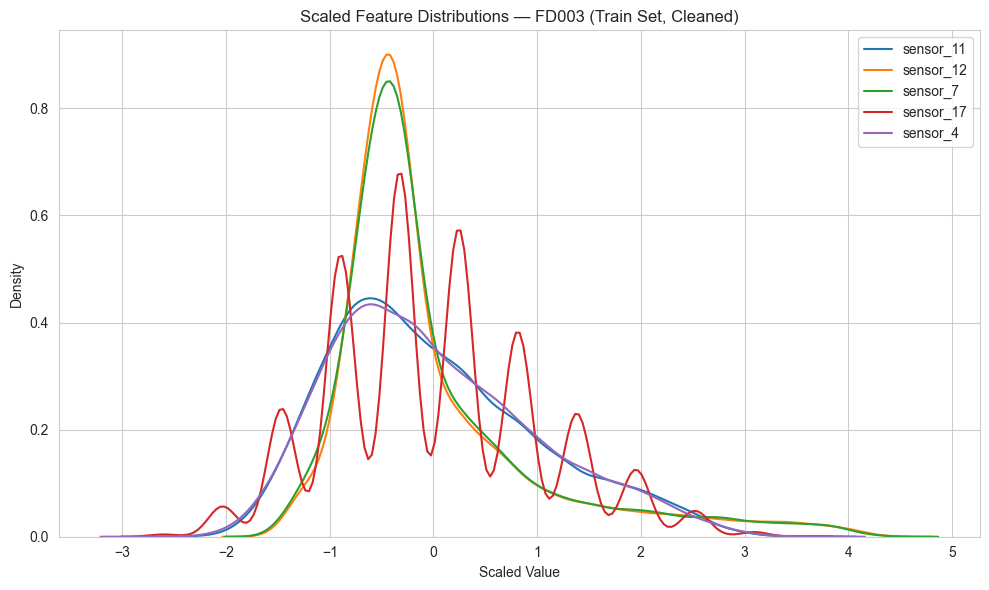

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Confirm consistent formatting
RANDOM_STATE = 42
top5_sensors_fd003 = ['sensor_11', 'sensor_12', 'sensor_7', 'sensor_17', 'sensor_4']

# A. Train/Test labels
print("Train Labels:", sorted(np.unique(y_train_fd003_clean)))
print("Test Labels :", sorted(np.unique(y_test_fd003_clean)))
print("Overlapping Classes:", set(y_train_fd003_clean) & set(y_test_fd003_clean))

# B. Distribution check
print("\nClass distribution in y_train_fd003_clean:")
print(pd.Series(y_train_fd003_clean).value_counts(normalize=True).sort_index())

print("\nClass distribution in y_test_fd003_clean:")
print(pd.Series(y_test_fd003_clean).value_counts(normalize=True).sort_index())

# C. CV on training only
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_model_fd003 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv_scores = cross_val_score(
    rf_model_fd003,
    X_train_fd003_clean,
    y_train_fd003_clean,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("\nCV F1 Macro Scores (Train Set):", cv_scores)
print("Mean F1 Macro Score:", np.mean(cv_scores))

# D. Overlap check
train_rows = set(map(tuple, X_train_fd003_clean))
test_rows = set(map(tuple, X_test_fd003_clean))
overlap_count = len(train_rows & test_rows)
print(f"\nOverlap rows between train and test: {overlap_count}")

# E. Visual Check: Scaled Distributions
plt.figure(figsize=(10, 6))
for i, sensor in enumerate(top5_sensors_fd003):
    sns.kdeplot(X_train_scaled_fd003_clean[:, i], label=sensor)

plt.title("Scaled Feature Distributions — FD003 (Train Set, Cleaned)")
plt.xlabel("Scaled Value")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Step 3.4: Clean Train/Test Data + Refit Scaler

In [9]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Top 5 variance sensors for FD003
top5_sensors_fd003 = ['sensor_11', 'sensor_12', 'sensor_7', 'sensor_17', 'sensor_4']

# 1. Prepare train DataFrame with label
X_train_df = pd.DataFrame(X_train_fd003, columns=top5_sensors_fd003)
X_train_df['label'] = y_train_fd003.values

# 2. Drop duplicates
X_train_df = X_train_df.drop_duplicates()

# 3. Extract cleaned train arrays
X_train_fd003_clean = X_train_df.drop(columns='label').values
y_train_fd003_clean = X_train_df['label'].values

# 4. Prepare test DataFrame and remove overlaps
X_test_df = pd.DataFrame(X_test_fd003, columns=top5_sensors_fd003)
X_test_df['label'] = y_test_fd003.values

train_set = set(map(tuple, X_train_fd003_clean))
X_test_df = X_test_df[~X_test_df[top5_sensors_fd003].apply(tuple, axis=1).isin(train_set)]

# 5. Extract cleaned test arrays
X_test_fd003_clean = X_test_df[top5_sensors_fd003].values
y_test_fd003_clean = X_test_df['label'].values

# 6. Refit scaler on cleaned training set
scaler_fd003 = StandardScaler()
X_train_scaled_fd003_clean = scaler_fd003.fit_transform(X_train_fd003_clean)
X_test_scaled_fd003_clean = scaler_fd003.transform(X_test_fd003_clean)

# 7. Final status
print("Data leakage & duplicates removed successfully (FD003).")
print("Final Clean Shapes:")
print(f"  X_train_fd003_clean: {X_train_fd003_clean.shape}")
print(f"  X_test_fd003_clean : {X_test_fd003_clean.shape}")


Data leakage & duplicates removed successfully (FD003).
Final Clean Shapes:
  X_train_fd003_clean: (19776, 5)
  X_test_fd003_clean : (4944, 5)


# Step 4: Random Forest + Evaluation + Sanity Checks (FD003)

 RF 5-Fold CV F1 Macro Scores (FD003, Cleaned): [0.91584776 0.93083804 0.92856071 0.92710346 0.92229752]
 Mean F1 Macro Score: 0.9249294983570493
 RF model saved at: ..\..\models\rf_fd003_model.pkl


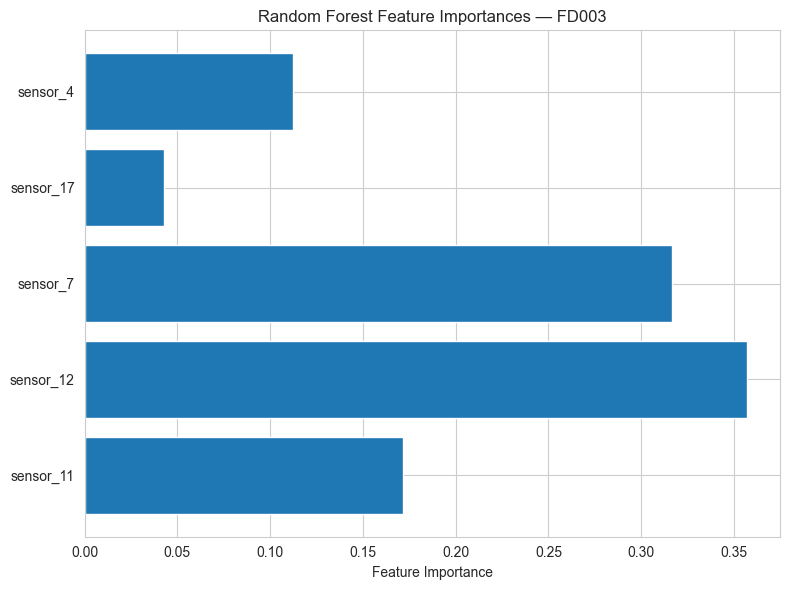

 Feature importance plot saved at: ..\..\figures\phase3\rf_fd003_feature_importances.png

 RF Test Accuracy: 0.9302
 RF Test Classification Report:

              precision    recall  f1-score   support

     Stage 0       0.97      0.97      0.97       238
     Stage 1       0.95      0.97      0.96      1411
     Stage 2       0.89      0.88      0.88       914
     Stage 3       0.88      0.86      0.87       348
     Stage 4       0.94      0.93      0.94      2033

    accuracy                           0.93      4944
   macro avg       0.93      0.92      0.92      4944
weighted avg       0.93      0.93      0.93      4944



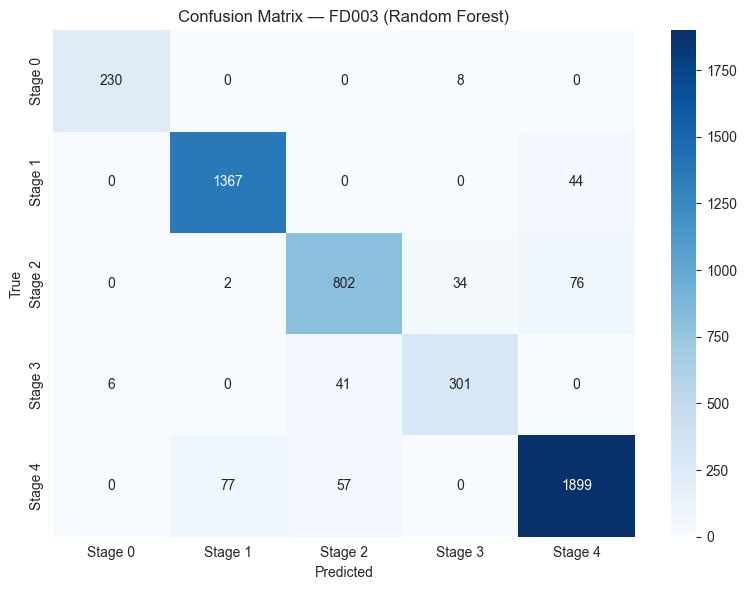

 Confusion matrix saved at: ..\..\figures\phase3\rf_fd003_confusion_matrix.png

 Sanity Check A — CV with Shuffled Labels
 CV F1 Scores (shuffled): [0.18266066 0.17826616 0.18144846 0.17844023 0.18586341]
 Mean F1 (shuffled): 0.18133578209062462

 Sanity Check B — Feature Correlation to Stage Label
 sensor_11 → Pearson correlation: -0.7315
 sensor_12 → Pearson correlation: -0.2561
 sensor_7 → Pearson correlation: -0.2410
 sensor_17 → Pearson correlation: -0.6791
 sensor_4 → Pearson correlation: -0.7031

 Sanity Check C — Depth=2 Decision Tree
 Tiny Tree Accuracy → Train: 0.8293 | Test: 0.8208


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
import pandas as pd
import os

# Define sensors
top5_sensors_fd003 = ['sensor_11', 'sensor_12', 'sensor_7', 'sensor_17', 'sensor_4']

# Create directories
os.makedirs('../../models', exist_ok=True)
os.makedirs('../../figures/phase3', exist_ok=True)

# 1. Initialize Random Forest
rf_model_fd003 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. 5-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf_fd003 = cross_val_score(
    rf_model_fd003,
    X_train_scaled_fd003_clean,
    y_train_fd003_clean,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)
print(" RF 5-Fold CV F1 Macro Scores (FD003, Cleaned):", cv_scores_rf_fd003)
print(" Mean F1 Macro Score:", np.mean(cv_scores_rf_fd003))

# 3. Train on Full Cleaned Training Set
rf_model_fd003.fit(X_train_scaled_fd003_clean, y_train_fd003_clean)

# 4. Save Trained Model
model_path = os.path.join('..', '..', 'models', 'rf_fd003_model.pkl')
joblib.dump(rf_model_fd003, model_path)
print(f" RF model saved at: {model_path}")

# 5. Feature Importances Plot
importances = rf_model_fd003.feature_importances_
plt.figure(figsize=(8, 6))
plt.barh(top5_sensors_fd003, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances — FD003")
plt.tight_layout()
plot_path = os.path.join('..', '..', 'figures', 'phase3', 'rf_fd003_feature_importances.png')
plt.savefig(plot_path)
plt.show()
print(f" Feature importance plot saved at: {plot_path}")

# Step 4.5: Evaluation on Cleaned Test Set
y_test_pred_rf = rf_model_fd003.predict(X_test_scaled_fd003_clean)
test_acc = accuracy_score(y_test_fd003_clean, y_test_pred_rf)
print(f"\n RF Test Accuracy: {test_acc:.4f}")
print(" RF Test Classification Report:\n")
print(classification_report(y_test_fd003_clean, y_test_pred_rf))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test_fd003_clean, y_test_pred_rf),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=rf_model_fd003.classes_,
    yticklabels=rf_model_fd003.classes_
)
plt.title("Confusion Matrix — FD003 (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
cm_path = os.path.join('..', '..', 'figures', 'phase3', 'rf_fd003_confusion_matrix.png')
plt.savefig(cm_path)
plt.show()
print(f" Confusion matrix saved at: {cm_path}")

#  Sanity Check A: CV with Shuffled Labels
print("\n Sanity Check A — CV with Shuffled Labels")
y_shuffled = shuffle(y_train_fd003_clean, random_state=42)
rf_shuffled = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
cv_shuffled = cross_val_score(rf_shuffled, X_train_scaled_fd003_clean, y_shuffled, cv=skf, scoring='f1_macro')
print(" CV F1 Scores (shuffled):", cv_shuffled)
print(" Mean F1 (shuffled):", np.mean(cv_shuffled))

#  Sanity Check B: Feature Correlation with Stage
print("\n Sanity Check B — Feature Correlation to Stage Label")
y_stage_numeric = pd.Series(y_train_fd003_clean).apply(lambda x: int(x[-1]))
for sensor in top5_sensors_fd003:
    col_index = top5_sensors_fd003.index(sensor)
    corr = pd.Series(X_train_scaled_fd003_clean[:, col_index]).corr(y_stage_numeric)
    print(f" {sensor} → Pearson correlation: {corr:.4f}")

#  Sanity Check C: Tiny Decision Tree (Depth = 2)
print("\n Sanity Check C — Depth=2 Decision Tree")
tiny_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tiny_tree.fit(X_train_scaled_fd003_clean, y_train_fd003_clean)
print(f" Tiny Tree Accuracy → Train: {tiny_tree.score(X_train_scaled_fd003_clean, y_train_fd003_clean):.4f} | Test: {tiny_tree.score(X_test_scaled_fd003_clean, y_test_fd003_clean):.4f}")


# Step 5: Final Evaluation of Random Forest on FD003 (Cleaned)

RF Train Accuracy: 1.0000
RF Test Accuracy : 0.9302
Reports saved at:
- c:\Users\pandr\hybrid-predictive-maintenance\report\rf_fd003_train_classification_report.txt
- c:\Users\pandr\hybrid-predictive-maintenance\report\rf_fd003_test_classification_report.txt


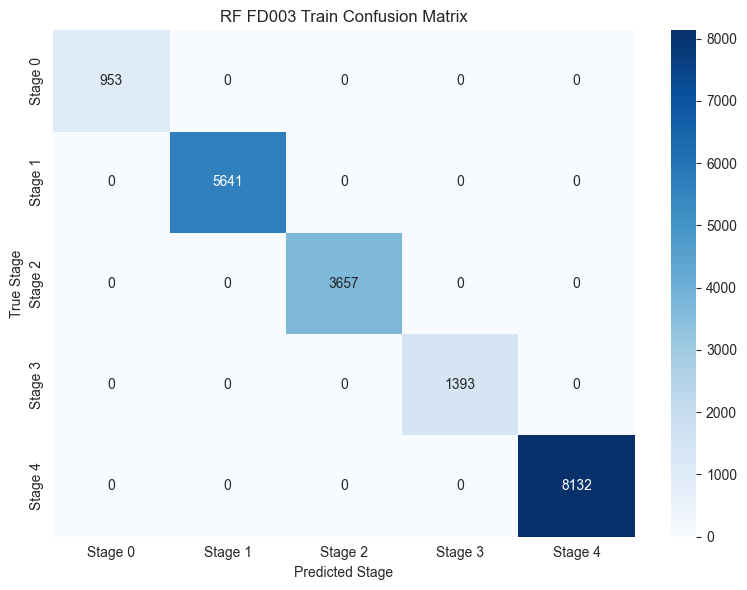

Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd003_train_conf_matrix.png


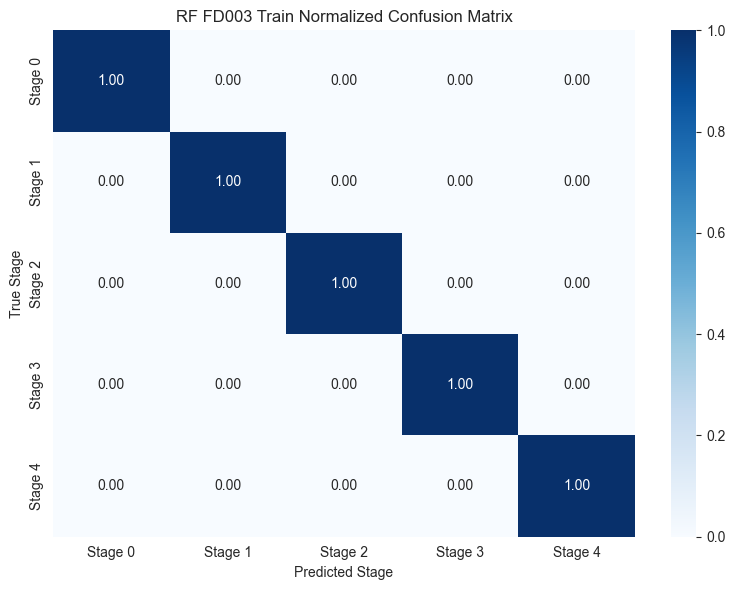

Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd003_train_conf_matrix_normalized.png


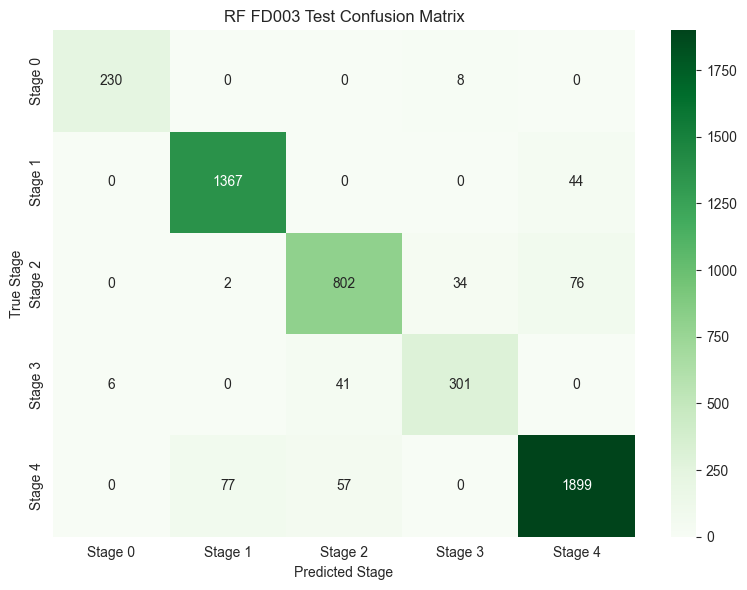

Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd003_test_conf_matrix.png


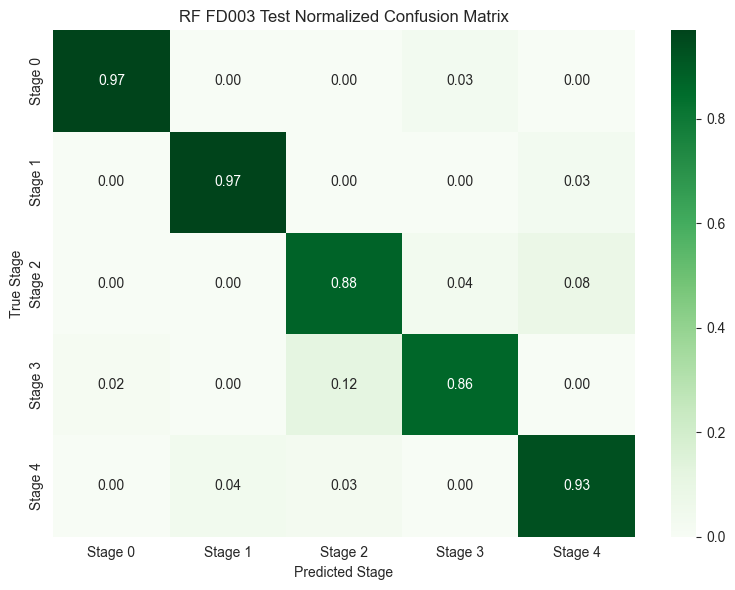

Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd003_test_conf_matrix_normalized.png


In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

# 1. Load trained model if not already loaded
model_path = os.path.join('..', '..', 'models', 'rf_fd003_model.pkl')
rf_model_fd003 = joblib.load(model_path)

# 2. Predict on Cleaned Train and Test Sets
y_train_pred_rf_fd003 = rf_model_fd003.predict(X_train_scaled_fd003_clean)
y_test_pred_rf_fd003 = rf_model_fd003.predict(X_test_scaled_fd003_clean)

# 3. Accuracy Scores
train_acc = accuracy_score(y_train_fd003_clean, y_train_pred_rf_fd003)
test_acc = accuracy_score(y_test_fd003_clean, y_test_pred_rf_fd003)
print(f"RF Train Accuracy: {train_acc:.4f}")
print(f"RF Test Accuracy : {test_acc:.4f}")

# 4. Save Classification Reports
report_dir = os.path.abspath(os.path.join('..', '..', 'report'))
os.makedirs(report_dir, exist_ok=True)

train_report_path = os.path.join(report_dir, 'rf_fd003_train_classification_report.txt')
test_report_path = os.path.join(report_dir, 'rf_fd003_test_classification_report.txt')

with open(train_report_path, 'w') as f:
    f.write(classification_report(y_train_fd003_clean, y_train_pred_rf_fd003))
with open(test_report_path, 'w') as f:
    f.write(classification_report(y_test_fd003_clean, y_test_pred_rf_fd003))

print(f"Reports saved at:\n- {train_report_path}\n- {test_report_path}")

# 5. Plot and Save Confusion Matrices
figures_dir = os.path.abspath(os.path.join('..', '..', 'figures', 'phase3'))
os.makedirs(figures_dir, exist_ok=True)

def save_conf_matrix(cm, title, filename, fmt='d', cmap='Blues'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=rf_model_fd003.classes_,
                yticklabels=rf_model_fd003.classes_)
    plt.title(title)
    plt.xlabel('Predicted Stage')
    plt.ylabel('True Stage')
    plt.tight_layout()
    path = os.path.join(figures_dir, filename)
    plt.savefig(path)
    plt.show()
    print(f"Saved: {path}")

# Train Confusion Matrices
cm_train = confusion_matrix(y_train_fd003_clean, y_train_pred_rf_fd003)
cm_train_norm = confusion_matrix(y_train_fd003_clean, y_train_pred_rf_fd003, normalize='true')
save_conf_matrix(cm_train, "RF FD003 Train Confusion Matrix", "rf_fd003_train_conf_matrix.png", 'd', 'Blues')
save_conf_matrix(cm_train_norm, "RF FD003 Train Normalized Confusion Matrix", "rf_fd003_train_conf_matrix_normalized.png", '.2f', 'Blues')

# Test Confusion Matrices
cm_test = confusion_matrix(y_test_fd003_clean, y_test_pred_rf_fd003)
cm_test_norm = confusion_matrix(y_test_fd003_clean, y_test_pred_rf_fd003, normalize='true')
save_conf_matrix(cm_test, "RF FD003 Test Confusion Matrix", "rf_fd003_test_conf_matrix.png", 'd', 'Greens')
save_conf_matrix(cm_test_norm, "RF FD003 Test Normalized Confusion Matrix", "rf_fd003_test_conf_matrix_normalized.png", '.2f', 'Greens')


# Step 6: SVM Classifier + CV + Evaluation (FD003, Cleaned)

SVM 5-Fold CV F1 Macro Scores (FD003): [0.92409493 0.93331193 0.92814781 0.92489089 0.93128386]
Mean F1 Macro Score: 0.928345883112901
SVM model saved at: ..\..\models\svm_fd003_model.pkl
SVM Train Accuracy: 0.9314
SVM Test Accuracy : 0.9286
Classification reports saved.


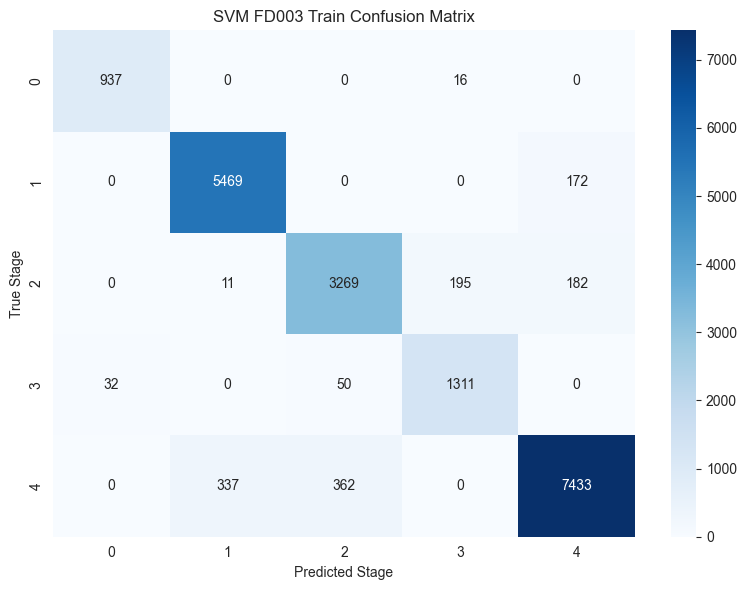

Saved: ..\..\figures\phase3\svm_fd003_train_conf_matrix.png


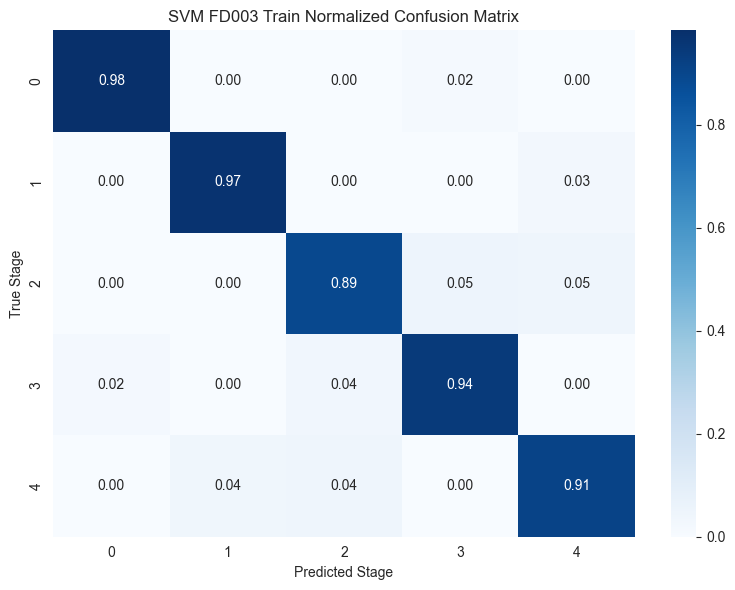

Saved: ..\..\figures\phase3\svm_fd003_train_conf_matrix_normalized.png


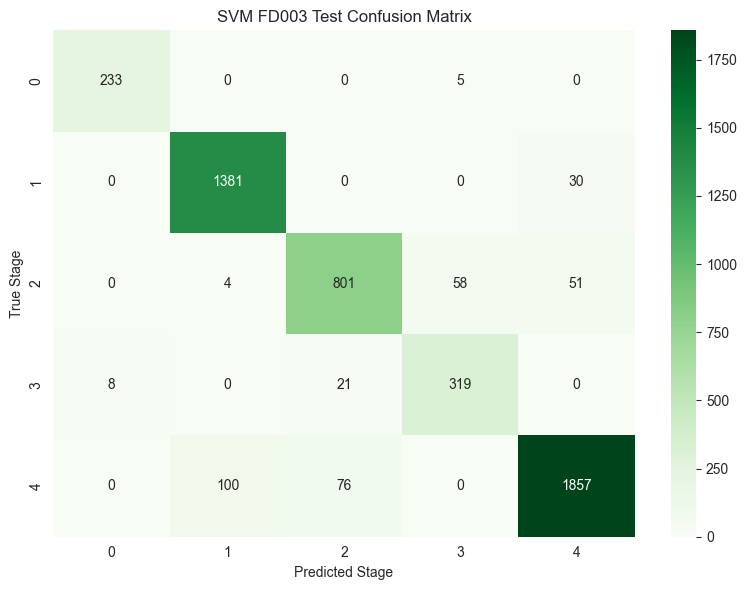

Saved: ..\..\figures\phase3\svm_fd003_test_conf_matrix.png


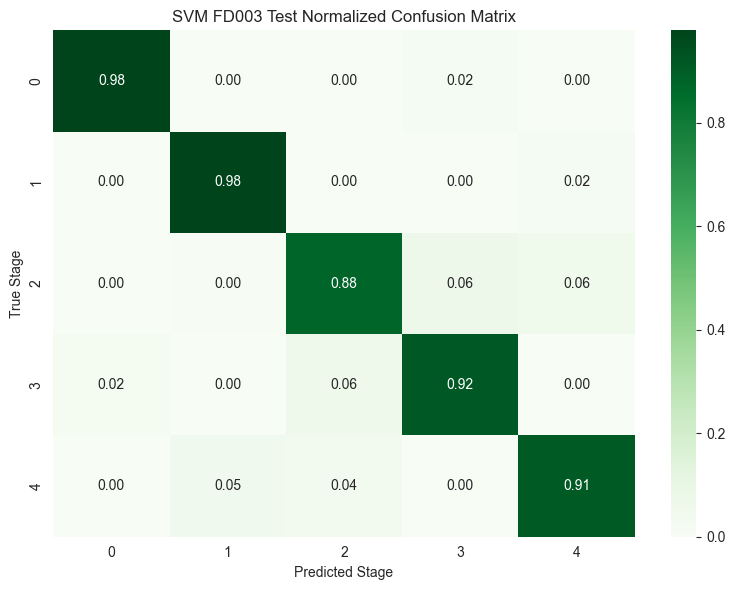

Saved: ..\..\figures\phase3\svm_fd003_test_conf_matrix_normalized.png


In [15]:
# Step 6: SVM Classifier + CV + Evaluation (FD003, Cleaned)

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

# 1. Initialize SVM Classifier
svm_model_fd003 = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=False,
    random_state=42
)

# 2. 5-Fold Cross Validation on Scaled Cleaned Data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_svm_fd003 = cross_val_score(
    svm_model_fd003,
    X_train_scaled_fd003_clean,
    y_train_fd003_clean,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("SVM 5-Fold CV F1 Macro Scores (FD003):", cv_scores_svm_fd003)
print("Mean F1 Macro Score:", np.mean(cv_scores_svm_fd003))

# 3. Train on full cleaned training set
svm_model_fd003.fit(X_train_scaled_fd003_clean, y_train_fd003_clean)

# 4. Save the trained model
model_path = os.path.join('..', '..', 'models', 'svm_fd003_model.pkl')
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(svm_model_fd003, model_path)
print(f"SVM model saved at: {model_path}")

# 5. Predict on train and test sets
y_train_pred_svm_fd003 = svm_model_fd003.predict(X_train_scaled_fd003_clean)
y_test_pred_svm_fd003 = svm_model_fd003.predict(X_test_scaled_fd003_clean)

# 6. Accuracy reporting
print(f"SVM Train Accuracy: {accuracy_score(y_train_fd003_clean, y_train_pred_svm_fd003):.4f}")
print(f"SVM Test Accuracy : {accuracy_score(y_test_fd003_clean, y_test_pred_svm_fd003):.4f}")

# 7. Save classification reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'svm_fd003_train_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_train_fd003_clean, y_train_pred_svm_fd003))

with open(os.path.join(report_dir, 'svm_fd003_test_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test_fd003_clean, y_test_pred_svm_fd003))

print("Classification reports saved.")

# 8. Plot confusion matrices
def plot_conf_matrix(y_true, y_pred, title_prefix, filename_prefix, cmap):
    fig_dir = os.path.join('..', '..', 'figures', 'phase3')
    os.makedirs(fig_dir, exist_ok=True)

    # Raw confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap)
    plt.title(f"{title_prefix} Confusion Matrix")
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    raw_path = os.path.join(fig_dir, f"{filename_prefix}.png")
    plt.savefig(raw_path)
    plt.show()
    print(f"Saved: {raw_path}")

    # Normalized confusion matrix
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap)
    plt.title(f"{title_prefix} Normalized Confusion Matrix")
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    norm_path = os.path.join(fig_dir, f"{filename_prefix}_normalized.png")
    plt.savefig(norm_path)
    plt.show()
    print(f"Saved: {norm_path}")

# Plot train and test confusion matrices
plot_conf_matrix(y_train_fd003_clean, y_train_pred_svm_fd003, "SVM FD003 Train", "svm_fd003_train_conf_matrix", 'Blues')
plot_conf_matrix(y_test_fd003_clean, y_test_pred_svm_fd003, "SVM FD003 Test", "svm_fd003_test_conf_matrix", 'Greens')


# Step 7: Logistic Regression Classifier + Evaluation (FD003)

Logistic Regression 5-Fold CV F1 Macro Scores (FD003):
[0.92160046 0.93264502 0.92716038 0.92649286 0.93200427]
Mean F1 Macro Score: 0.927980597743724
Trained Logistic Regression model saved at: ..\..\models\lr_fd003_model.pkl
Logistic Regression Train Accuracy: 0.9302
Logistic Regression Test Accuracy : 0.9290
Classification reports saved.


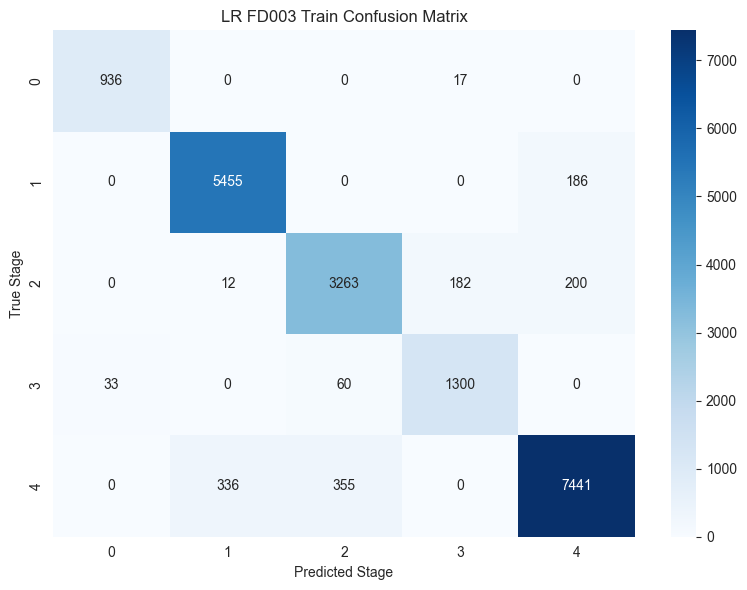

Saved: ..\..\figures\phase3\lr_fd003_train_conf_matrix.png


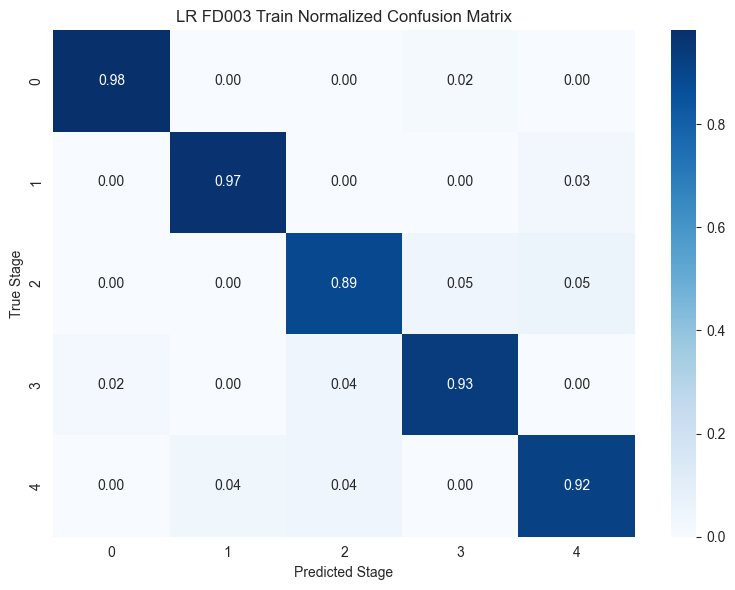

Saved: ..\..\figures\phase3\lr_fd003_train_conf_matrix_normalized.png


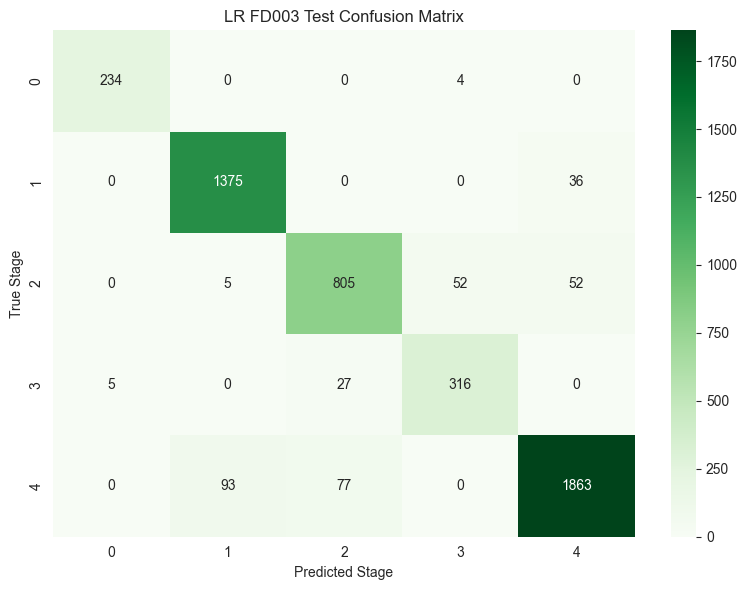

Saved: ..\..\figures\phase3\lr_fd003_test_conf_matrix.png


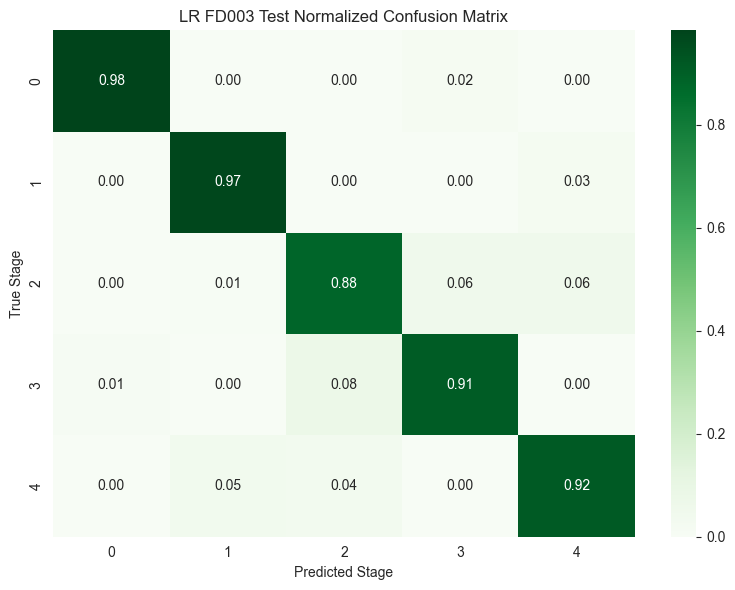

Saved: ..\..\figures\phase3\lr_fd003_test_conf_matrix_normalized.png


In [17]:
# Step 7: Logistic Regression Classifier + Evaluation (FD003)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import numpy as np

# 1. Initialize Logistic Regression Model
lr_model_fd003 = LogisticRegression(
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# 2. Stratified 5-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr_fd003 = cross_val_score(
    lr_model_fd003,
    X_train_scaled_fd003_clean,
    y_train_fd003_clean,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("Logistic Regression 5-Fold CV F1 Macro Scores (FD003):")
print(cv_scores_lr_fd003)
print("Mean F1 Macro Score:", np.mean(cv_scores_lr_fd003))

# 3. Train on Full Cleaned Training Set
lr_model_fd003.fit(X_train_scaled_fd003_clean, y_train_fd003_clean)

# 4. Save Model
model_path = os.path.join('..', '..', 'models', 'lr_fd003_model.pkl')
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(lr_model_fd003, model_path)
print(f"Trained Logistic Regression model saved at: {model_path}")

# 5. Predictions
y_train_pred = lr_model_fd003.predict(X_train_scaled_fd003_clean)
y_test_pred = lr_model_fd003.predict(X_test_scaled_fd003_clean)

print(f"Logistic Regression Train Accuracy: {accuracy_score(y_train_fd003_clean, y_train_pred):.4f}")
print(f"Logistic Regression Test Accuracy : {accuracy_score(y_test_fd003_clean, y_test_pred):.4f}")

# 6. Save Classification Reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'lr_fd003_train_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_train_fd003_clean, y_train_pred))

with open(os.path.join(report_dir, 'lr_fd003_test_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test_fd003_clean, y_test_pred))

print("Classification reports saved.")

# 7. Save Confusion Matrices
def save_conf_matrix(cm, title, filename, fmt, cmap):
    path = os.path.join('..', '..', 'figures', 'phase3', filename)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    print(f"Saved: {path}")

# 8. Plot and Save All Confusion Matrices
save_conf_matrix(confusion_matrix(y_train_fd003_clean, y_train_pred),
                 "LR FD003 Train Confusion Matrix", "lr_fd003_train_conf_matrix.png", 'd', 'Blues')

save_conf_matrix(confusion_matrix(y_train_fd003_clean, y_train_pred, normalize='true'),
                 "LR FD003 Train Normalized Confusion Matrix", "lr_fd003_train_conf_matrix_normalized.png", '.2f', 'Blues')

save_conf_matrix(confusion_matrix(y_test_fd003_clean, y_test_pred),
                 "LR FD003 Test Confusion Matrix", "lr_fd003_test_conf_matrix.png", 'd', 'Greens')

save_conf_matrix(confusion_matrix(y_test_fd003_clean, y_test_pred, normalize='true'),
                 "LR FD003 Test Normalized Confusion Matrix", "lr_fd003_test_conf_matrix_normalized.png", '.2f', 'Greens')


# Step 8: XGBoost Classifier for FD003

Label Encoding Done. Classes: ['Stage 0' 'Stage 1' 'Stage 2' 'Stage 3' 'Stage 4']
XGBoost 5-Fold CV F1 Macro Scores (FD003): [0.92443984 0.93451671 0.93009123 0.92601273 0.92608402]
Mean F1 Macro Score: 0.9282289064013785
Trained XGBoost model saved at: ..\..\models\xgb_fd003_model.pkl
XGBoost Train Accuracy: 0.9549
XGBoost Test Accuracy : 0.9335
Classification reports saved.


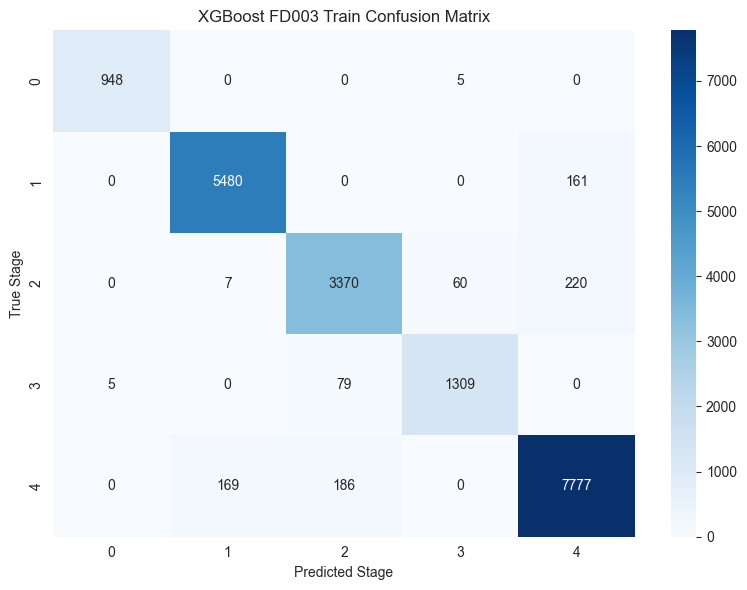

Saved: ..\..\figures\phase3\xgb_fd003_train_conf_matrix.png


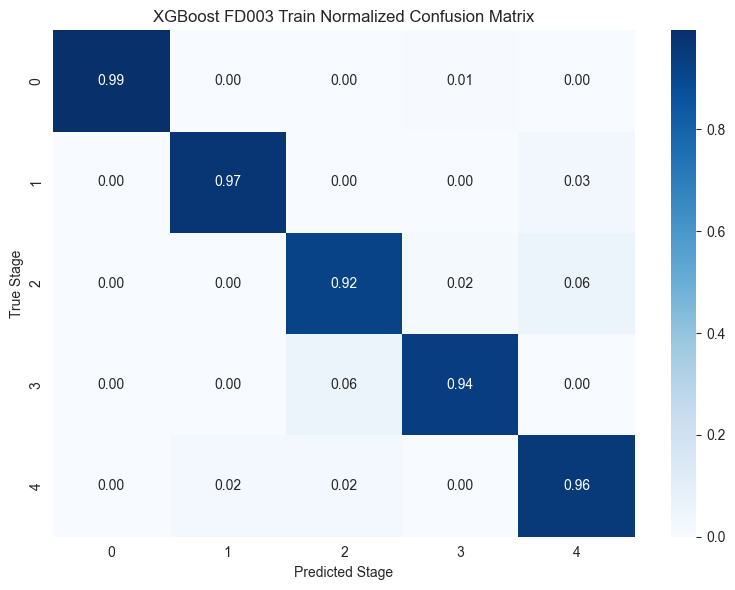

Saved: ..\..\figures\phase3\xgb_fd003_train_conf_matrix_normalized.png


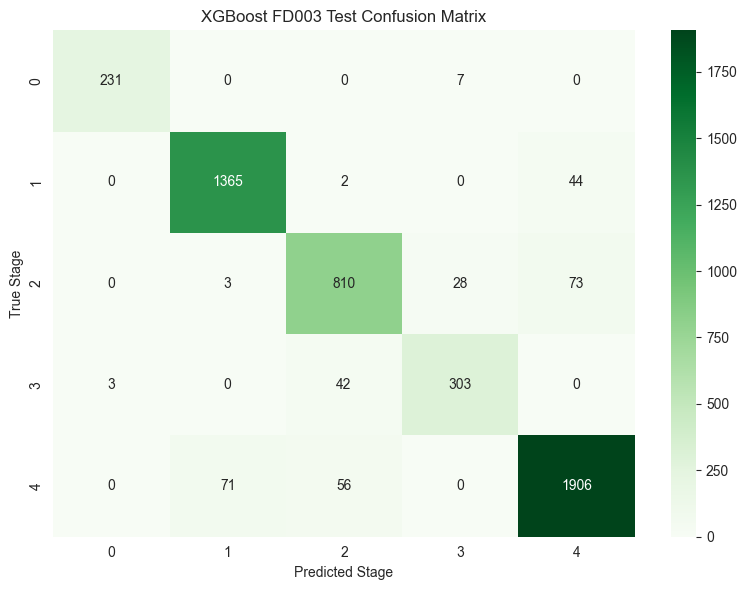

Saved: ..\..\figures\phase3\xgb_fd003_test_conf_matrix.png


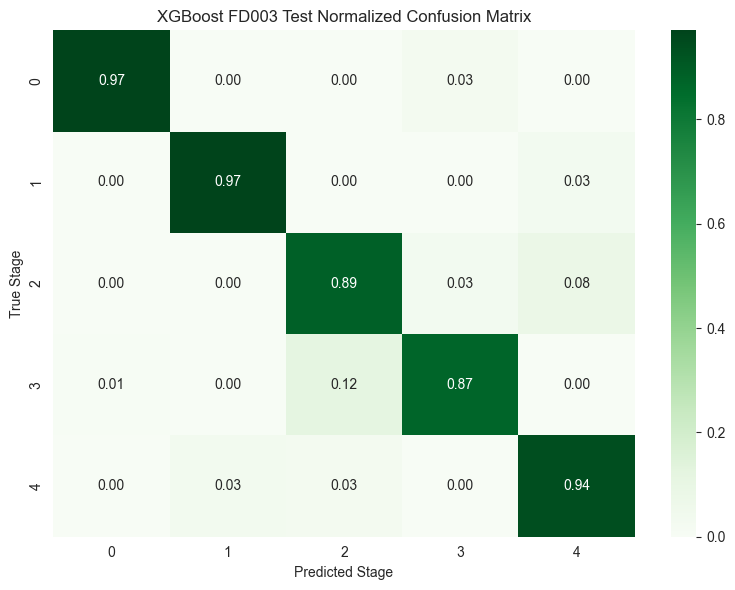

Saved: ..\..\figures\phase3\xgb_fd003_test_conf_matrix_normalized.png


In [19]:
# Step 8.0: Label Encoding for FD003
from sklearn.preprocessing import LabelEncoder
import numpy as np
import os

label_encoder = LabelEncoder()
y_train_fd003_encoded = label_encoder.fit_transform(y_train_fd003_clean)
y_test_fd003_encoded = label_encoder.transform(y_test_fd003_clean)
print("Label Encoding Done. Classes:", label_encoder.classes_)

# Step 8.1: XGBoost Classifier Training + Evaluation (FD003)
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize Model (no use_label_encoder)
xgb_model_fd003 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE
)

# 2. 5-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_xgb = cross_val_score(
    xgb_model_fd003,
    X_train_fd003_clean,
    y_train_fd003_encoded,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)
print("XGBoost 5-Fold CV F1 Macro Scores (FD003):", cv_scores_xgb)
print("Mean F1 Macro Score:", np.mean(cv_scores_xgb))

# 3. Train on full data
xgb_model_fd003.fit(X_train_fd003_clean, y_train_fd003_encoded)

# 4. Save the trained model
model_path = os.path.join('..', '..', 'models', 'xgb_fd003_model.pkl')
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(xgb_model_fd003, model_path)
print(f"Trained XGBoost model saved at: {model_path}")

# Step 8.5: Evaluation – Predictions and Decoding
y_train_pred = xgb_model_fd003.predict(X_train_fd003_clean)
y_test_pred = xgb_model_fd003.predict(X_test_fd003_clean)

y_train_pred_decoded = label_encoder.inverse_transform(y_train_pred)
y_test_pred_decoded = label_encoder.inverse_transform(y_test_pred)
y_train_true_decoded = label_encoder.inverse_transform(y_train_fd003_encoded)
y_test_true_decoded = label_encoder.inverse_transform(y_test_fd003_encoded)

print(f"XGBoost Train Accuracy: {accuracy_score(y_train_true_decoded, y_train_pred_decoded):.4f}")
print(f"XGBoost Test Accuracy : {accuracy_score(y_test_true_decoded, y_test_pred_decoded):.4f}")

# Step 8.6: Save Classification Reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'xgb_fd003_train_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_train_true_decoded, y_train_pred_decoded))

with open(os.path.join(report_dir, 'xgb_fd003_test_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test_true_decoded, y_test_pred_decoded))

print("Classification reports saved.")

# Step 8.7: Confusion Matrix Plotting
def save_conf_matrix(cm, title, filename, fmt, cmap):
    fig_dir = os.path.join('..', '..', 'figures', 'phase3')
    os.makedirs(fig_dir, exist_ok=True)
    path = os.path.join(fig_dir, filename)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel('Predicted Stage')
    plt.ylabel('True Stage')
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    print(f"Saved: {path}")

# Step 8.8: Save All Confusion Matrices for FD003
save_conf_matrix(confusion_matrix(y_train_true_decoded, y_train_pred_decoded),
                 "XGBoost FD003 Train Confusion Matrix", "xgb_fd003_train_conf_matrix.png", 'd', 'Blues')

save_conf_matrix(confusion_matrix(y_train_true_decoded, y_train_pred_decoded, normalize='true'),
                 "XGBoost FD003 Train Normalized Confusion Matrix", "xgb_fd003_train_conf_matrix_normalized.png", '.2f', 'Blues')

save_conf_matrix(confusion_matrix(y_test_true_decoded, y_test_pred_decoded),
                 "XGBoost FD003 Test Confusion Matrix", "xgb_fd003_test_conf_matrix.png", 'd', 'Greens')

save_conf_matrix(confusion_matrix(y_test_true_decoded, y_test_pred_decoded, normalize='true'),
                 "XGBoost FD003 Test Normalized Confusion Matrix", "xgb_fd003_test_conf_matrix_normalized.png", '.2f', 'Greens')


# Step A: Random Forest Hyperparameter Tuning (FD003)

In [20]:
# Step A: Random Forest Hyperparameter Tuning (FD003)

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Load Corrected + Clustered FD003 Data
fd003_path = os.path.join('..', '..', 'data', 'corrected_clustered_train_FD003.csv')
df_fd003 = pd.read_csv(fd003_path)
print("Corrected FD003 dataset loaded successfully.")

# 2. Select Top 5 Sensor Features (based on prior feature importance or variance)
top5_sensors_fd003 = ['sensor_11', 'sensor_4', 'sensor_13', 'sensor_12', 'sensor_7']  # Example
X_fd003 = df_fd003[top5_sensors_fd003]
y_fd003 = df_fd003['kmeans_stage']
print("Feature and target variables selected.")

# 3. Stratified Train-Test Split
X_train_fd003, X_test_fd003, y_train_fd003, y_test_fd003 = train_test_split(
    X_fd003,
    y_fd003,
    test_size=0.2,
    stratify=y_fd003,
    random_state=42
)
print(f"Train/Test split complete. Train shape: {X_train_fd003.shape}, Test shape: {X_test_fd003.shape}")

# 4. Define Hyperparameter Grid
param_grid_rf_fd003 = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 5. Setup GridSearchCV with Stratified K-Fold
rf_base_model = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_search_rf_fd003 = GridSearchCV(
    estimator=rf_base_model,
    param_grid=param_grid_rf_fd003,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=2
)

# 6. Execute Grid Search
print("Starting Grid Search for FD003 Random Forest...")
grid_search_rf_fd003.fit(X_train_fd003, y_train_fd003)

# 7. Output Best Model Details
print("\nGrid Search Completed.")
print("Best Parameters:", grid_search_rf_fd003.best_params_)
print("Best F1 Macro Score:", grid_search_rf_fd003.best_score_)

# 8. Retrain Final Model on Entire Training Data
best_rf_fd003 = grid_search_rf_fd003.best_estimator_
best_rf_fd003.fit(X_train_fd003, y_train_fd003)

# 9. Save the Best Model
model_save_path = os.path.abspath(os.path.join('..', '..', 'models', 'rf_fd003_best_model.pkl'))
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
joblib.dump(best_rf_fd003, model_save_path)
print(f"Best Random Forest model saved at: {model_save_path}")

Corrected FD003 dataset loaded successfully.
Feature and target variables selected.
Train/Test split complete. Train shape: (19776, 5), Test shape: (4944, 5)
Starting Grid Search for FD003 Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Grid Search Completed.
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Macro Score: 0.9222100741937845
Best Random Forest model saved at: c:\Users\pandr\hybrid-predictive-maintenance\models\rf_fd003_best_model.pkl


# Phase 3 (FD003) – Step B: Evaluation (Tuned Random Forest)

 RF Tuned Train Accuracy: 0.9493
 RF Tuned Test Accuracy : 0.9177
 Classification reports saved in: ..\..\report


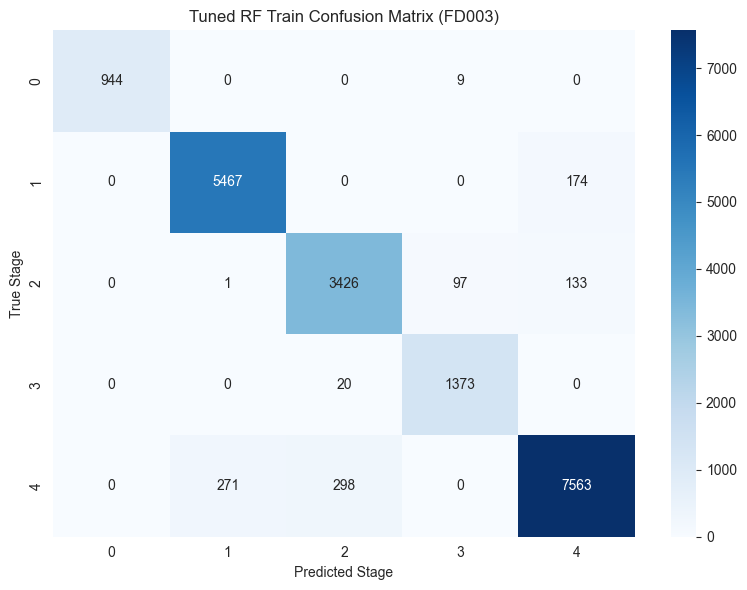

 Saved: ..\..\figures\phase3\rf_fd003_train_conf_matrix_tuned.png


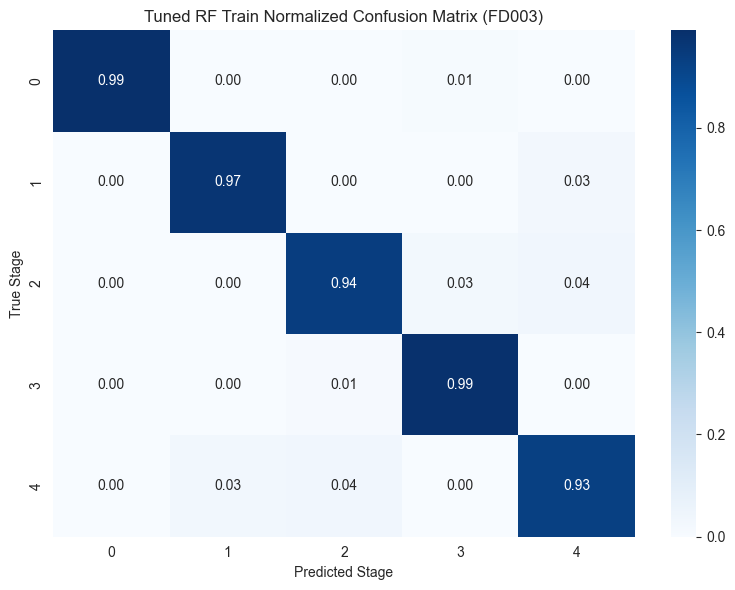

 Saved: ..\..\figures\phase3\rf_fd003_train_conf_matrix_normalized_tuned.png


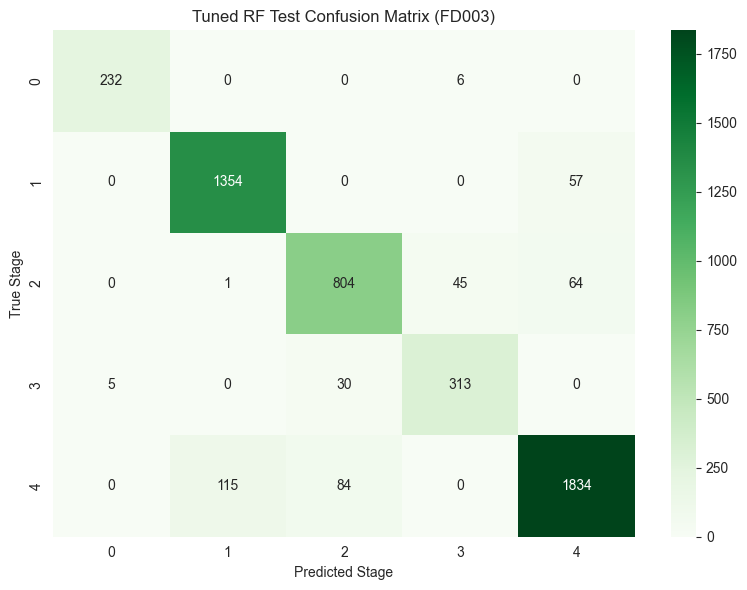

 Saved: ..\..\figures\phase3\rf_fd003_test_conf_matrix_tuned.png


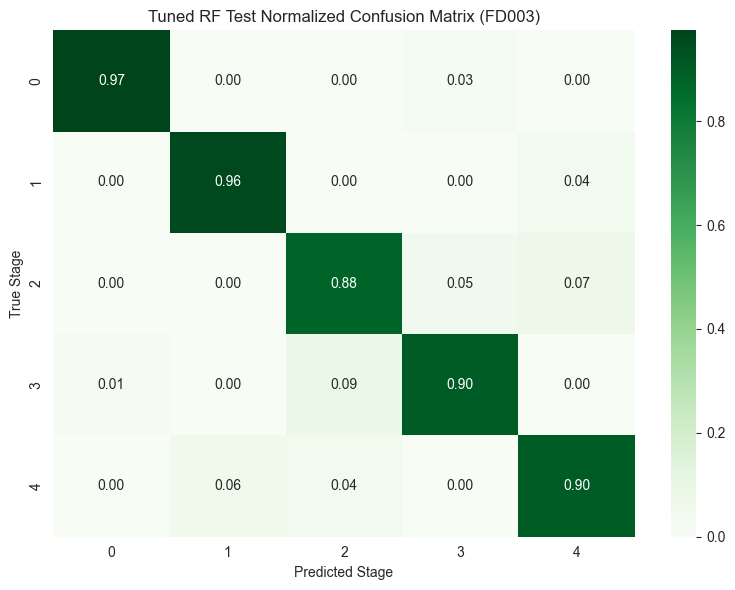

 Saved: ..\..\figures\phase3\rf_fd003_test_conf_matrix_normalized_tuned.png


In [21]:
# Phase 3 (FD003) – Step B: Evaluation (Tuned Random Forest)

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Predict using the best RF model
y_train_pred = best_rf_fd003.predict(X_train_fd003)
y_test_pred = best_rf_fd003.predict(X_test_fd003)

# 2. Accuracy Scores
print(f" RF Tuned Train Accuracy: {accuracy_score(y_train_fd003, y_train_pred):.4f}")
print(f" RF Tuned Test Accuracy : {accuracy_score(y_test_fd003, y_test_pred):.4f}")

# 3. Save Classification Reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'rf_fd003_train_classification_report_tuned.txt'), 'w') as f:
    f.write(classification_report(y_train_fd003, y_train_pred))

with open(os.path.join(report_dir, 'rf_fd003_test_classification_report_tuned.txt'), 'w') as f:
    f.write(classification_report(y_test_fd003, y_test_pred))

print(f" Classification reports saved in: {report_dir}")

# 4. Confusion Matrix Plotting Function
fig_dir = os.path.join('..', '..', 'figures', 'phase3')
os.makedirs(fig_dir, exist_ok=True)

def save_conf_matrix(cm, title, filename, fmt, cmap):
    path = os.path.join(fig_dir, filename)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    print(f" Saved: {path}")

# 5. Train Confusion Matrices
cm_train = confusion_matrix(y_train_fd003, y_train_pred)
cm_train_norm = confusion_matrix(y_train_fd003, y_train_pred, normalize='true')
save_conf_matrix(cm_train, "Tuned RF Train Confusion Matrix (FD003)", "rf_fd003_train_conf_matrix_tuned.png", 'd', 'Blues')
save_conf_matrix(cm_train_norm, "Tuned RF Train Normalized Confusion Matrix (FD003)", "rf_fd003_train_conf_matrix_normalized_tuned.png", '.2f', 'Blues')

# 6. Test Confusion Matrices
cm_test = confusion_matrix(y_test_fd003, y_test_pred)
cm_test_norm = confusion_matrix(y_test_fd003, y_test_pred, normalize='true')
save_conf_matrix(cm_test, "Tuned RF Test Confusion Matrix (FD003)", "rf_fd003_test_conf_matrix_tuned.png", 'd', 'Greens')
save_conf_matrix(cm_test_norm, "Tuned RF Test Normalized Confusion Matrix (FD003)", "rf_fd003_test_conf_matrix_normalized_tuned.png", '.2f', 'Greens')


# Phase 3 (FD003) – Step C: Confusion Matrices (Tuned RF)

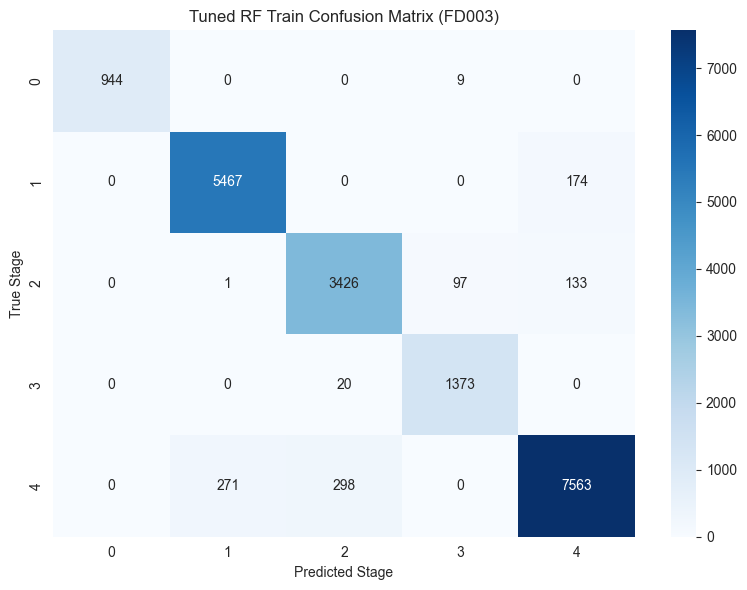

 Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd003_train_conf_matrix_tuned.png


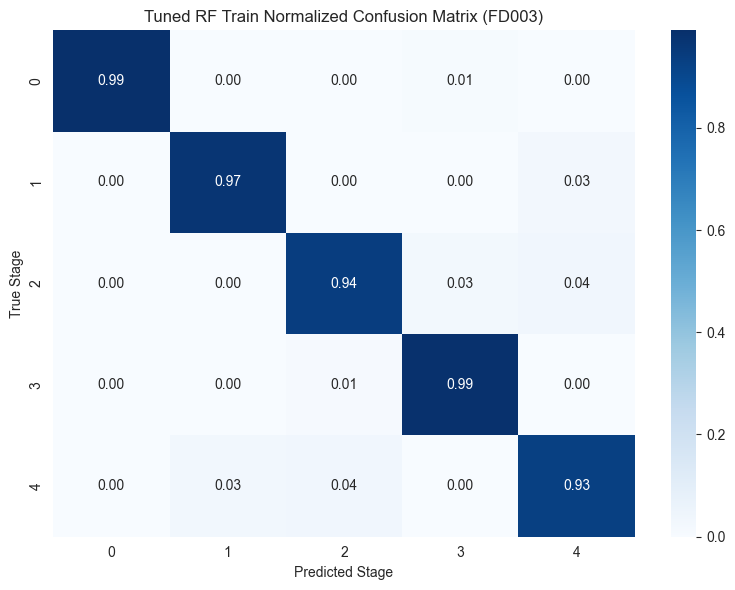

 Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd003_train_conf_matrix_normalized_tuned.png


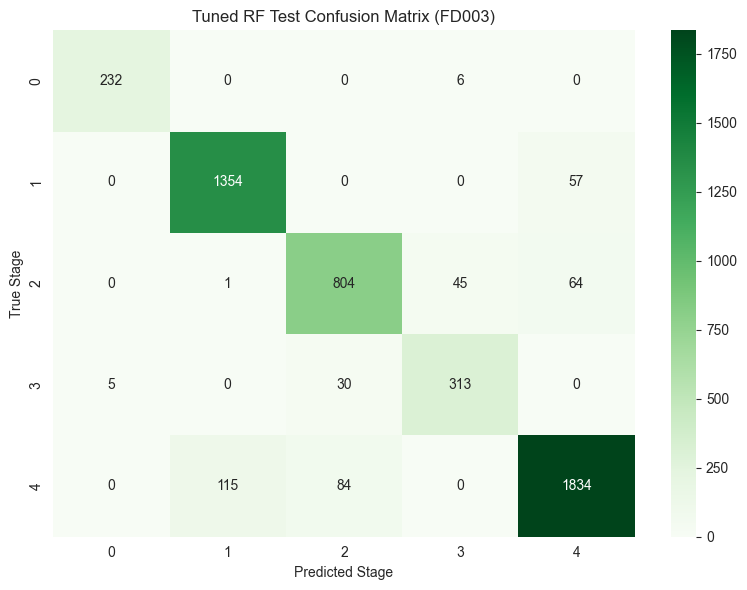

 Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd003_test_conf_matrix_tuned.png


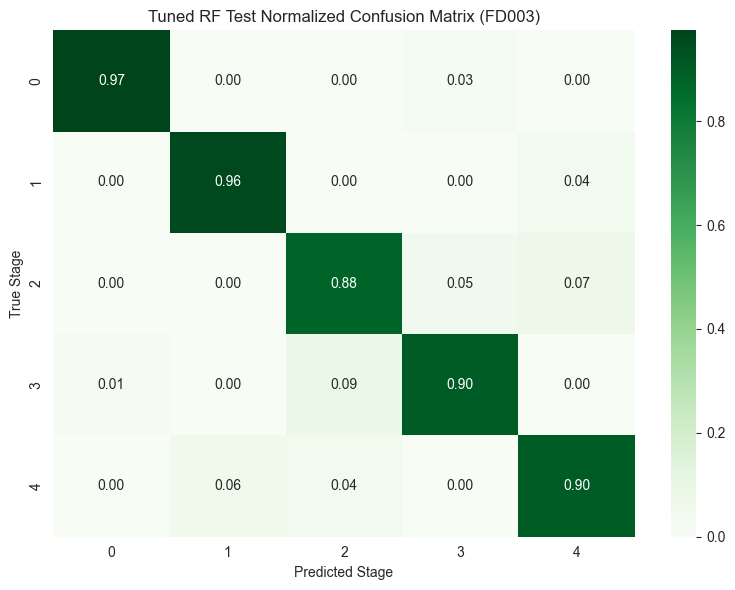

 Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd003_test_conf_matrix_normalized_tuned.png


In [22]:
# Phase 3 (FD003) – Step C: Confusion Matrices (Tuned RF)

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Ensure figure directory exists
fig_dir = os.path.abspath(os.path.join('..', '..', 'figures', 'phase3'))
os.makedirs(fig_dir, exist_ok=True)

# 2. Define Confusion Matrix Plotting Function
def save_conf_matrix(cm, title, filename, fmt='d', cmap='Blues'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel('Predicted Stage')
    plt.ylabel('True Stage')
    plt.tight_layout()
    fig_path = os.path.join(fig_dir, filename)
    plt.savefig(fig_path)
    plt.show()
    print(f" Saved: {fig_path}")

# 3. Train Confusion Matrices
cm_train_fd003 = confusion_matrix(y_train_fd003, y_train_pred)
cm_train_fd003_norm = confusion_matrix(y_train_fd003, y_train_pred, normalize='true')

save_conf_matrix(
    cm_train_fd003,
    "Tuned RF Train Confusion Matrix (FD003)",
    "rf_fd003_train_conf_matrix_tuned.png",
    fmt='d',
    cmap='Blues'
)

save_conf_matrix(
    cm_train_fd003_norm,
    "Tuned RF Train Normalized Confusion Matrix (FD003)",
    "rf_fd003_train_conf_matrix_normalized_tuned.png",
    fmt='.2f',
    cmap='Blues'
)

# 4. Test Confusion Matrices
cm_test_fd003 = confusion_matrix(y_test_fd003, y_test_pred)
cm_test_fd003_norm = confusion_matrix(y_test_fd003, y_test_pred, normalize='true')

save_conf_matrix(
    cm_test_fd003,
    "Tuned RF Test Confusion Matrix (FD003)",
    "rf_fd003_test_conf_matrix_tuned.png",
    fmt='d',
    cmap='Greens'
)

save_conf_matrix(
    cm_test_fd003_norm,
    "Tuned RF Test Normalized Confusion Matrix (FD003)",
    "rf_fd003_test_conf_matrix_normalized_tuned.png",
    fmt='.2f',
    cmap='Greens'
)


# Phase 3 (FD003) – Final Step: Model Comparison Table and Bar Plot

Model Comparison Table (FD003):

                   Model  Train Accuracy  Test Accuracy  \
0  Random Forest (Tuned)          0.9493         0.9177   
1                    SVM          0.9314         0.9286   
2    Logistic Regression          0.9302         0.9290   
3                XGBoost          0.9549         0.9335   

   Mean F1 Macro Score (CV)  
0                    0.9222  
1                    0.9283  
2                    0.9280  
3                    0.9282  

Model Comparison Table saved at:
c:\Users\pandr\hybrid-predictive-maintenance\report\phase3_model_comparison_fd003.csv


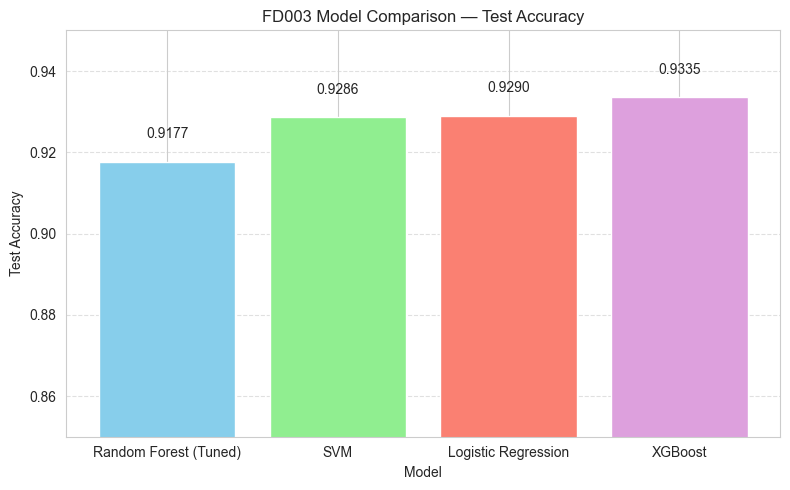


Bar Plot saved at:
c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\model_comparison_test_accuracy_fd003.png


In [24]:
# Phase 3 (FD003) – Final Step: Model Comparison Table and Bar Plot

import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Define Final Evaluation Results for FD003 (Corrected)
model_comparison_fd003 = {
    'Model': ['Random Forest (Tuned)', 'SVM', 'Logistic Regression', 'XGBoost'],
    'Train Accuracy': [
        0.9493,  # Tuned RF
        0.9314,  # SVM
        0.9302,  # Logistic Regression
        0.9549   # XGBoost
    ],
    'Test Accuracy': [
        0.9177,  # Tuned RF
        0.9286,  # SVM
        0.9290,  # Logistic Regression
        0.9335   # XGBoost
    ],
    'Mean F1 Macro Score (CV)': [
        0.9222,  # Tuned RF
        0.9283,  # SVM
        0.9280,  # Logistic Regression
        0.9282   # XGBoost
    ]
}

# 2. Create DataFrame
comparison_df_fd003 = pd.DataFrame(model_comparison_fd003)
print("Model Comparison Table (FD003):\n")
print(comparison_df_fd003)

# 3. Ensure output folders exist
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
report_dir = os.path.join(base_dir, 'report')
figures_dir = os.path.join(base_dir, 'figures', 'phase3')
os.makedirs(report_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

# 4. Save table to CSV
comparison_csv_path = os.path.join(report_dir, 'phase3_model_comparison_fd003.csv')
comparison_df_fd003.to_csv(comparison_csv_path, index=False)
print(f"\nModel Comparison Table saved at:\n{comparison_csv_path}")

# 5. Bar Chart – Test Accuracy
plt.figure(figsize=(8, 5))
bar_colors = ['skyblue', 'lightgreen', 'salmon', 'plum']
bars = plt.bar(comparison_df_fd003['Model'], comparison_df_fd003['Test Accuracy'], color=bar_colors)

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.005,
             f'{height:.4f}', ha='center', va='bottom')

plt.ylim(0.85, 0.95)
plt.title('FD003 Model Comparison — Test Accuracy')
plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# 6. Save plot
plot_path = os.path.join(figures_dir, 'model_comparison_test_accuracy_fd003.png')
plt.savefig(plot_path)
plt.show()
print(f"\nBar Plot saved at:\n{plot_path}")
